# Business Entity Resolution — EDA & Visualization
Amazon ML Challenge 2026. This notebook explores the 3 sources + ground truth to inform **blocking** and **matching-feature** design.

**Memory note:** the raw TSVs total ~2.4 GB. Everything is loaded with `pyarrow` and kept as Arrow-backed pandas columns (`pd.ArrowDtype`), which is roughly 1x file size in RAM instead of ~5x for Python object strings. Heavy per-row Python work is done on **samples** only.

Sections:
1. Load data & basic shape
2. Country distribution (train vs test, France!)
3. Ground-truth structure (matches per entity, singletons, S2 vs S3)
4. Field completeness & length
5. Scripts / transliteration (Devanagari, Kannada, accents...)
6. Name noise patterns (junk prefixes, legal suffixes, DBA, domains)
7. Address patterns (postcodes, casing, state forms, house numbers)
8. Pair-level similarity: true matches vs random pairs
9. Blocking-key recall preview
10. Test set overview

In [1]:
import re, random, time, unicodedata, difflib, gc
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.compute as pc
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Notebook lives in student_resource/ (next to dataset/). Adjust if you move it.
ROOT = Path.cwd()
if not (ROOT / "dataset").exists():
    ROOT = Path(r"D:\downloads\hackathon\amazon ml  challenge\6a7c763e089e4_aic_2026\student_resource")
DATA = ROOT / "dataset"
print(DATA, [p.name for p in sorted(DATA.glob("*/*.tsv"))])

d:\downloads\hackathon\amazon ml  challenge\6a7c763e089e4_aic_2026\student_resource\dataset ['test_source1.tsv', 'test_source2.tsv', 'test_source3.tsv', 'train_ground_truth.tsv', 'train_source1.tsv', 'train_source2.tsv', 'train_source3.tsv']


In [2]:
STR_COLS = ["entity_id", "business_name", "business_address", "country",
            "source1_entity_id", "matched_entity_ids"]

def load_tsv(path):
    """Read a challenge TSV with pyarrow (tab-separated, no quoting) into an Arrow-backed DataFrame.
    Empty fields are kept as "" (not NaN), so a missing address == ""."""
    tbl = pacsv.read_csv(
        path,
        parse_options=pacsv.ParseOptions(delimiter="\t", quote_char=False),
        convert_options=pacsv.ConvertOptions(column_types={c: pa.string() for c in STR_COLS},
                                             strings_can_be_null=False),
    )
    return tbl.to_pandas(types_mapper=pd.ArrowDtype)

def mem_gb(df):
    return df.memory_usage(deep=True).sum() / 1e9

## 1. Load training data

In [3]:
t0 = time.time()
s1 = load_tsv(DATA / "train/train_source1.tsv")
s2 = load_tsv(DATA / "train/train_source2.tsv")
s3 = load_tsv(DATA / "train/train_source3.tsv")
gt = load_tsv(DATA / "train/train_ground_truth.tsv")
print(f"loaded in {time.time()-t0:.1f}s")
for n, d in [("S1", s1), ("S2", s2), ("S3", s3), ("GT", gt)]:
    print(f"{n}: {len(d):>10,} rows  {mem_gb(d):.2f} GB  cols={list(d.columns)}")

loaded in 3.7s
S1:  2,206,821 rows  0.24 GB  cols=['entity_id', 'business_name', 'business_address', 'country']
S2:  5,034,616 rows  0.55 GB  cols=['entity_id', 'business_name', 'business_address', 'country']
S3:  5,285,603 rows  0.57 GB  cols=['entity_id', 'business_name', 'business_address', 'country']
GT:  2,206,821 rows  0.14 GB  cols=['source1_entity_id', 'matched_entity_ids']


In [4]:
display(s1.head(5)); display(s2.head(5)); display(s3.head(5)); display(gt.head(5))

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West Bengal",India


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block Jayanagar, Bengaluru Urban, Bangalore, ಕರ್ನಾಟಕ",India


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364"
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-384364074"
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-728090388,S3-928796641,S3-449308785"


In [5]:
# Sanity checks: unique IDs, prefixes, GT covers every S1 exactly once
for n, d, p in [("S1", s1, "S1-"), ("S2", s2, "S2-"), ("S3", s3, "S3-")]:
    print(n, "unique ids:", d.entity_id.is_unique,
          "| all prefix ok:", bool(d.entity_id.str.startswith(p).all()))
print("GT rows == S1 rows:", len(gt) == len(s1),
      "| GT ids == S1 ids:", bool(gt.source1_entity_id.isin(s1.entity_id).all()) and gt.source1_entity_id.is_unique)

S1 unique ids: True | all prefix ok: True
S2 unique ids: True | all prefix ok: True
S3 unique ids: True | all prefix ok: True
GT rows == S1 rows: True | GT ids == S1 ids: True


## 2. Country distribution
Train has only US / India. Test adds **France** (no labels), so features must be country-agnostic.

,S1,S2,S3
country,,,
US,1323633,3016817,3170056
India,883188,2017799,2115547


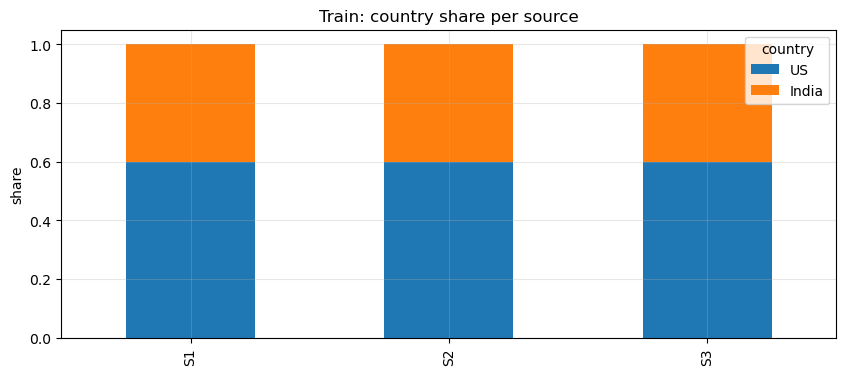

In [6]:
cc = pd.DataFrame({n: d.country.value_counts() for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]}).fillna(0).astype(int)
display(cc)
(cc / cc.sum()).T.plot.bar(stacked=True, title="Train: country share per source"); plt.ylabel("share"); plt.show()

## 3. Ground-truth structure

In [7]:
# Explode the comma-separated match lists into a (s1_id, m_id) pair table using Arrow (fast, low-memory)
gt_tbl = pa.Table.from_pandas(gt, preserve_index=False)
lists = pc.split_pattern(gt_tbl["matched_entity_ids"].combine_chunks(), ",")
flat = pc.list_flatten(lists)
parent = pc.list_parent_indices(lists)
keep = pc.not_equal(flat, "")                       # empty GT field -> [""] -> drop
pairs = pa.table({"s1_id": pc.take(gt_tbl["source1_entity_id"], pc.filter(parent, keep)),
                  "m_id": pc.filter(flat, keep)}).to_pandas(types_mapper=pd.ArrowDtype)
pairs["m_src"] = pairs.m_id.str.slice(0, 2)

gt["n_s2"] = gt.matched_entity_ids.str.count("S2-")
gt["n_s3"] = gt.matched_entity_ids.str.count("S3-")
gt["n_match"] = gt.n_s2 + gt.n_s3
print(f"true pairs: {len(pairs):,} | singletons (no match): {(gt.n_match == 0).mean():.2%} "
      f"| mean matches/entity: {gt.n_match.mean():.2f}")
print(pairs.m_src.value_counts())

true pairs: 7,638,365 | singletons (no match): 5.58% | mean matches/entity: 3.46
m_src
S3    3944746
S2    3693619
Name: count, dtype: int64[pyarrow]


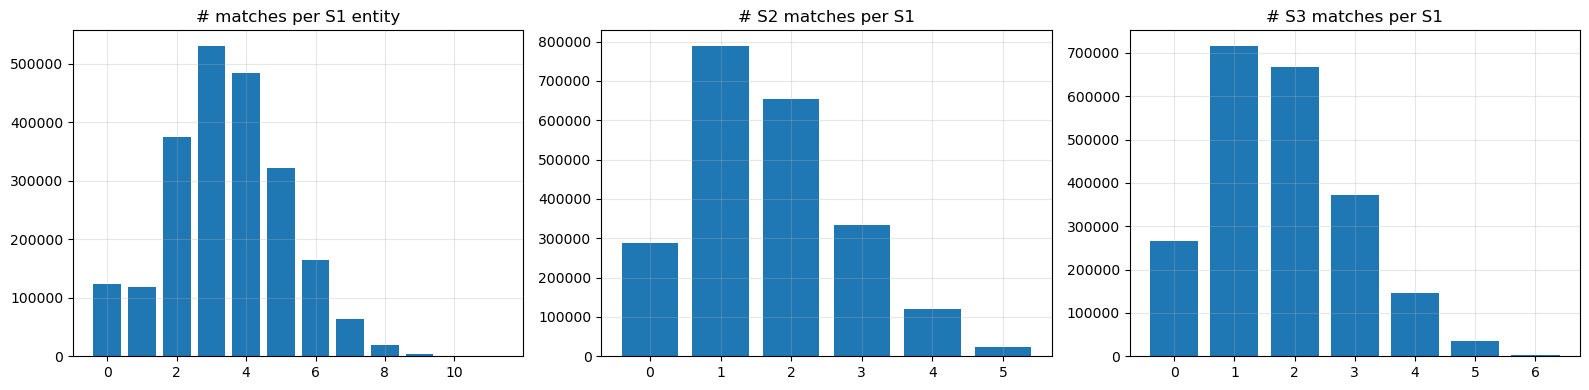

,entities,singleton_rate,mean_matches,mean_s2,mean_s3
country,,,,,
India,883188,0.055878,3.464543,1.676364,1.788179
US,1323633,0.055828,3.459057,1.671969,1.787088


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c, a, t in [("n_match", ax[0], "# matches per S1 entity"), ("n_s2", ax[1], "# S2 matches per S1"),
                ("n_s3", ax[2], "# S3 matches per S1")]:
    v = gt[c].value_counts().sort_index(); a.bar(v.index.astype(int), v.values); a.set_title(t)
plt.tight_layout(); plt.show()

g = gt.merge(s1[["entity_id", "country"]], left_on="source1_entity_id", right_on="entity_id")
display(g.groupby("country").agg(entities=("n_match", "size"),
                                 singleton_rate=("n_match", lambda x: (x == 0).mean()),
                                 mean_matches=("n_match", "mean"), mean_s2=("n_s2", "mean"), mean_s3=("n_s3", "mean")))
del g

In [9]:
# How many S2/S3 records are linked to any S1? The rest are distractors (businesses not in S1).
# Is each S2/S3 record linked to at most one S1 entity? (If yes -> a 1-to-1 assignment constraint is usable.)
per_m = pairs.m_id.value_counts()
print("S2/S3 ids linked to >1 S1 entity:", int((per_m > 1).sum()))
for n, d in [("S2", s2), ("S3", s3)]:
    linked = d.entity_id.isin(pairs.m_id).mean()
    print(f"{n}: {linked:.2%} of records are a true match of some S1 entity; {1-linked:.2%} are distractors")

S2/S3 ids linked to >1 S1 entity: 0
S2: 73.36% of records are a true match of some S1 entity; 26.64% are distractors
S3: 74.63% of records are a true match of some S1 entity; 25.37% are distractors


## 4. Field completeness & length

S1     S2     S3
business_name    empty%        0.00   0.00   0.00
                 mean_len     24.03  25.10  25.20
                 mean_tokens   3.55   3.50   3.53
business_address empty%        0.00   3.36   3.33
                 mean_len     52.07  46.23  46.71
                 mean_tokens   8.03   7.32   7.21

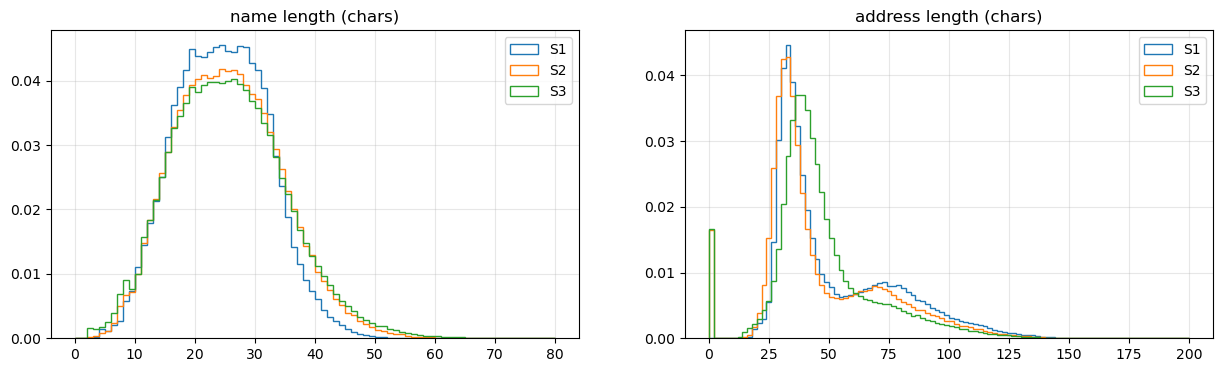

In [10]:
def field_stats(d):
    out = {}
    for c in ["business_name", "business_address"]:
        s = d[c]
        out[(c, "empty%")] = (s.str.strip() == "").mean() * 100
        out[(c, "mean_len")] = s.str.len().mean()
        out[(c, "mean_tokens")] = s.str.count(r"\s+").mean() + 1
    return pd.Series(out)
display(pd.DataFrame({n: field_stats(d) for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]}).round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
    smp = d.sample(200_000, random_state=SEED)
    ax[0].hist(smp.business_name.str.len(), bins=80, range=(0, 80), histtype="step", label=n, density=True)
    ax[1].hist(smp.business_address.str.len(), bins=100, range=(0, 200), histtype="step", label=n, density=True)
ax[0].set_title("name length (chars)"); ax[1].set_title("address length (chars)"); ax[0].legend(); ax[1].legend(); plt.show()

## 5. Scripts & transliteration
Indian records contain native scripts (Devanagari, Kannada, Tamil...) for names/states; US records have injected accents (a -> á). Normalising to a common script is likely a big win.

In [11]:
def script_of(ch):
    """Coarse Unicode script bucket of a non-ASCII character (e.g. DEVANAGARI, KANNADA, LATIN-ACCENT)."""
    if ch.isascii(): return None
    try: name = unicodedata.name(ch)
    except ValueError: return "OTHER"
    first = name.split()[0]
    return "LATIN-ACCENT" if first == "LATIN" else first

def scripts_in(text):
    return {s for s in map(script_of, text) if s}

def script_table(d, col, n=100_000):
    smp = d.sample(n, random_state=SEED)
    rows = []
    for ctry, grp in smp.groupby("country"):
        cnt = Counter()
        for t in grp[col].tolist():
            sc = scripts_in(t); cnt.update(sc if sc else {"ASCII-only"})
        rows += [(ctry, k, v / len(grp)) for k, v in cnt.items()]
    return pd.DataFrame(rows, columns=["country", "script", "share"])

for col in ["business_name", "business_address"]:
    tabs = []
    for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
        t = script_table(d, col); t["src"] = n; tabs.append(t)
    t = pd.concat(tabs).pivot_table(index=["country", "script"], columns="src", values="share").fillna(0)
    print(f"--- {col}: % of records containing each script ---")
    display((t * 100).round(2).sort_values("S2", ascending=False).head(15))

--- business_name: % of records containing each script ---


src                      S1     S2     S3
country script                           
US      ASCII-only    100.0  93.43  93.23
India   ASCII-only    100.0  72.21  81.42
        DEVANAGARI      0.0  13.32   7.40
US      LATIN-ACCENT    0.0   6.57   6.77
India   LATIN-ACCENT    0.0   4.28   5.35
        TELUGU          0.0   1.93   1.12
        KANNADA         0.0   1.88   1.03
        TAMIL           0.0   1.61   1.00
        BENGALI         0.0   1.56   0.92
        GUJARATI        0.0   1.54   0.87
        ZERO            0.0   1.23   0.71
        MALAYALAM       0.0   0.95   0.51
        ORIYA           0.0   0.37   0.21
        GURMUKHI        0.0   0.36   0.17

--- business_address: % of records containing each script ---


src                       S1      S2      S3
country script                              
US      ASCII-only    100.00  100.00  100.00
India   ASCII-only     99.93   76.19   77.15
        DEVANAGARI      0.00   14.08   13.19
        KANNADA         0.00    1.87    1.89
        GUJARATI        0.00    1.62    1.53
        TELUGU          0.00    1.60    1.67
        TAMIL           0.00    1.57    1.62
        BENGALI         0.00    1.56    1.51
        MALAYALAM       0.00    0.81    0.73
        GURMUKHI        0.00    0.33    0.40
        ORIYA           0.00    0.33    0.27
        LATIN-ACCENT    0.07    0.04    0.06
        OTHER           0.07    0.04    0.06
US      LATIN-ACCENT    0.00    0.00    0.00

In [12]:
# Examples of native-script names in S2/S3
for n, d in [("S2", s2), ("S3", s3)]:
    ex = d[(d.country == "India") & ~d.business_name.str.contains(r"^[\x00-\x7F]*$", regex=True)].sample(8, random_state=1)
    print(n); display(ex)

S2


,entity_id,business_name,business_address,country
1620495,S2-914130577,डायनामिक इनोवेटिव प्रोड्यूसर,"512, BELA, JOGAPUR KASHIRAM COLONY, PRATAPGARH, उत्तर प्रदेश",India
2499154,S2-816242186,सेवन कंसल्टेंट्स कंस्ट्रक्शंस प्राइवेट लिमिटेड,"NO 59, FIRST FLOOR, EAZE ZONE MALL, OFF LINK ROAD, GOREGAON (WEST), BOMBAY, Maharashtra",India
4880216,S2-157617741,ಈಸ್ಟರ್ನ್ ಕನ್ಸಲ್ಟೆನ್ಸಿ ಲಿಮಿಟೆಡ್,"III STAGE, IST MAIN ROAD 6TH BLOCK III PHASE, C.K B.S.K, BANGALORE, Karnataka, NO 55",India
2363613,S2-118592309,लक्ष्मी इंफ्रा प्रा. लि.,"B-9/6285 VASANT KUNJ, SOUTH WEST DELHI, Delhi",India
2529167,S2-839316057,राज सॉफ्टवेयर प्राइवेट लिमिटेड,"HOUSE NO.621- SECTOR- 22 B, GURGAON, Haryana",India
497263,S2-769882949,ಕ್ರಿಯೇಟಿವ್ ಗುಡ್ ಟೆಕ್ನಾಲಜೀಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"#285, AVERAHALLI INDUSTRIAL AREA, 4TH PHASE, DABASPETE, NELAMANGALA TALUK, BANGALORE RURAL, BANGALORE, Karnataka",India
247545,S2-879881430,शिवम एग्रो लिमिटेड,"83, NEW DELHI, N/A, दिल्ली",India
1615832,S2-537863802,ಫ್ಯೂಚರ್ ಎನರ್ಜಿ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"NO. 83 S6-1202, SMONDOVILLE, PHASE 1, NEOTOWN, BANGALORE SOUTH, BANGALORE, Karnataka",India


S3


,entity_id,business_name,business_address,country
2586550,S3-371670659,अल्फा कंसल्टेंसी लिमिटेड,"C/o Rai Shankar Narain Prasad Verma, Gudri Bazar Ward No - 17, Sitamarhi, बिहार",India
2314676,S3-558743195,Metro & Sóns Private Limited,"No 09, Pintars Nagar Colony, Sitabadi, Tonk Road, Jaipur, RJ",India
50657,S3-492678895,Dream Téchnologies Ltd,"Door No 0018, Crystal Plaza Shopping Complex, Jawahar Marg, Near Chanchal Chauraha, Barwani, Barwani, MP",India
3167613,S3-112698859,साउथ सॉफ्टवेयर प्राइवेट लिमिटेड,"Flat No. #13, Bombay, Mumbai City, MH",India
4740405,S3-779576078,हरि इंजीनियरिंग प्रा. लि.,"Sham Traders 7, New Cloth Market, Ambala City, HR",India
3355795,S3-188570486,સેવન બિલ્ડર્સ પ્રાઇવેટ લિમિટેડ,"#3/2206, 1St Floor And 2Nd Floor, B/h Police Line, Salabatpura, Surat, Surat City, GJ",India
314755,S3-310446363,háriinternational.com,"Office No.201 And 202, MH, Pune",India
5220920,S3-607979027,ईस्टर्न वेंचर्स प्राइवेट लिमिटेड,"मध्य प्रदेश, Ujjain, D-196, Alkapuri",India


## 6. Name noise patterns

,S1,S2,S3
"junk_prefix (--, ***, <<, ...)",0.00,10.52,6.07
brackets () [],2.03,7.69,8.00
ALL CAPS,0.00,18.97,2.91
domain (.com/.in/...),0.00,3.13,3.20
DBA / formerly / aka,0.00,0.00,1.70
"honorific (Sri, Shri, Dr, The)",0.10,3.92,4.33
ampersand &,5.04,4.19,4.19
double space,0.00,10.99,10.87
"digit inside word (1/l, 0/o)",0.00,1.74,1.70


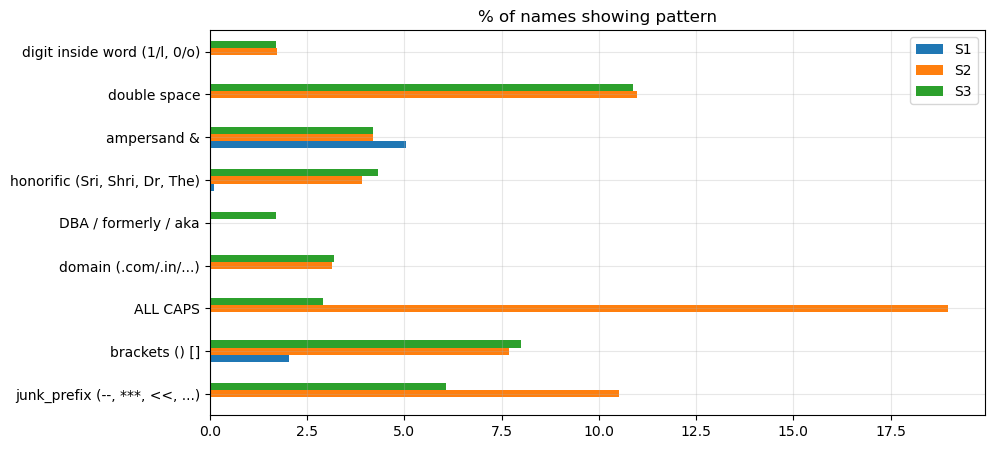

In [13]:
PATTERNS = {
    "junk_prefix (--, ***, <<, ...)": r"^\s*[^\w\s\(\[]{2,}",
    "brackets () []":                 r"[\(\)\[\]]",
    "ALL CAPS":                       r"^[^a-z]*[A-Z][^a-z]*$",
    "domain (.com/.in/...)":          r"\.(?:com|in|net|org|co|io|fr)\b",
    "DBA / formerly / aka":           r"(?i)\b(?:dba|d/b/a|formerly|aka|t/a)\b",
    "honorific (Sri, Shri, Dr, The)": r"(?i)^(?:the|sri|shri|dr|m/s|mr|smt)\b",
    "ampersand &":                    r"&",
    "double space":                   r"\s{2}",
    "digit inside word (1/l, 0/o)":   r"[A-Za-z][0-9][A-Za-z]",
}
rows = {}
for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
    smp = d.sample(300_000, random_state=SEED).business_name
    rows[n] = {k: smp.str.contains(p, regex=True).mean() * 100 for k, p in PATTERNS.items()}
pt = pd.DataFrame(rows).round(2); display(pt)
pt.plot.barh(figsize=(10, 5), title="% of names showing pattern"); plt.show()

C:\Users\KARAN PRATAP LOHIYA\AppData\Local\Temp\ipykernel_19000\3214791140.py:10: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\KARAN PRATAP LOHIYA\AppData\Local\Temp\ipykernel_19000\3214791140.py:10: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout(); plt.show()
C:\Users\KARAN PRATAP LOHIYA\AppData\Local\Temp\ipykernel_19000\3214791140.py:10: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\KARAN PRATAP LOHIYA\AppData\Local\Temp\ipykernel_19000\3214791140.py:10: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\KARAN PRATAP LOHIYA\AppData\Local\Temp\ipykernel_19000\3214791140.py:10: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\KARAN PRATAP LOHI

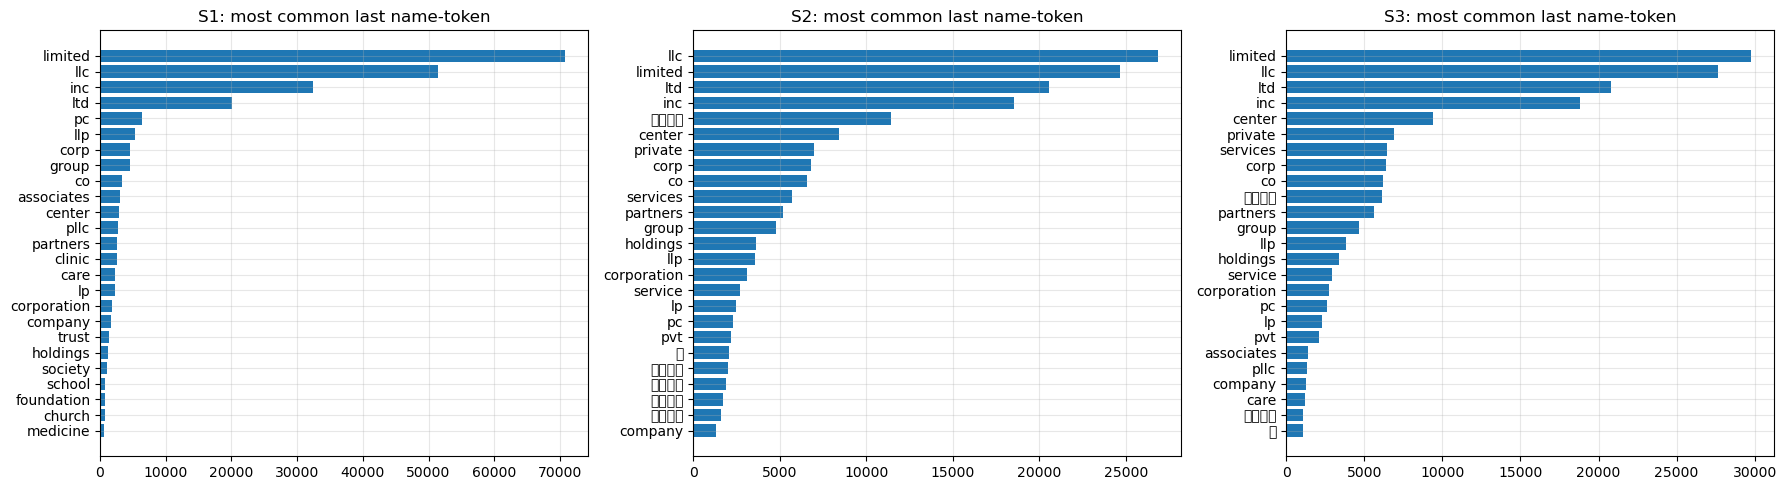

In [14]:
# Legal-suffix vocabulary: last token of the name (lower-cased, punctuation stripped)
def last_tok(s):
    toks = s.astype(str).str.lower().str.replace(r"[^\w\s]", "", regex=True).str.split()
    return toks.map(lambda t: t[-1] if len(t) else "")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for a, (n, d) in zip(axes, [("S1", s1), ("S2", s2), ("S3", s3)]):
    lt = last_tok(d.sample(300_000, random_state=SEED).business_name).value_counts().head(25)
    a.barh(lt.index[::-1].astype(str), lt.values[::-1]); a.set_title(f"{n}: most common last name-token")
plt.tight_layout(); plt.show()

In [15]:
# Top name tokens overall -> candidates for a stop-word / normalisation map (Pvt, Ltd, Inc, Corp, LLC ...)
tok = Counter()
for t in s2.sample(200_000, random_state=SEED).business_name.str.lower().tolist():
    tok.update(re.findall(r"[a-z0-9]+", t))
display(pd.DataFrame(tok.most_common(60), columns=["token", "count"]).set_index("token").T)

token,private,limited,llc,ltd,inc,l,com,center,pvt,s,...,shri,smt,highland,international,incorporated,foundation,harbor,trust,valley,coastal
count,21451,21135,21016,16136,15967,8020,7834,7832,7608,6278,...,1007,1006,997,996,993,973,964,956,950,947


## 7. Address patterns

In [16]:
ADDR_PATTERNS = {
    "US ZIP (5 digits)":          r"\b\d{5}(?:-\d{4})?\b",
    "IN PIN (6 digits)":          r"\b\d{6}\b",
    "starts with number":         r"^\s*\d",
    "ALL CAPS":                   r"^[^a-z]*[A-Z][^a-z]*$",
    "landmark (Near/Opp/Behind)": r"(?i)\b(?:near|opp|opposite|behind|beside)\b",
    "PO BOX":                     r"(?i)\bp\.?\s?o\.?\s?box\b",
    "unit / apt / suite / #":     r"(?i)(?:\bunit\b|\bapt\b|\bsuite\b|#)",
    "H.no / Door / Plot / Flat":  r"(?i)\b(?:h\.?\s?no|door no|plot no|flat no|shop no|khasra|kh no)\b",
    "2-letter state token":       r"(?:,\s*|^)[A-Z]{2}(?:\s*,|$)",
}
rows = {}
for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
    smp = d.sample(300_000, random_state=SEED)
    for ctry, grp in smp.groupby("country"):
        rows[(n, ctry)] = {k: grp.business_address.str.contains(p, regex=True).mean() * 100 for k, p in ADDR_PATTERNS.items()}
display(pd.DataFrame(rows).round(2))

S1             S2            S3       
                            India      US  India     US  India     US
US ZIP (5 digits)            0.26   10.77   1.07  10.06   0.95  10.08
IN PIN (6 digits)            0.00    0.13   0.00   1.39   0.00   1.36
starts with number          25.79   85.99  17.94  73.00  17.74  73.48
ALL CAPS                     0.00    0.00  23.92  89.76   0.05   0.00
landmark (Near/Opp/Behind)  11.30    0.01   9.56   0.01   7.37   0.01
PO BOX                       0.01    0.00   0.00   1.65   0.00   1.55
unit / apt / suite / #       3.07   13.51  12.54   5.20  11.84  14.89
H.no / Door / Plot / Flat   19.90    0.00  23.65   0.00  21.49   0.00
2-letter state token         0.00  100.00   0.89  96.27  67.44   4.73

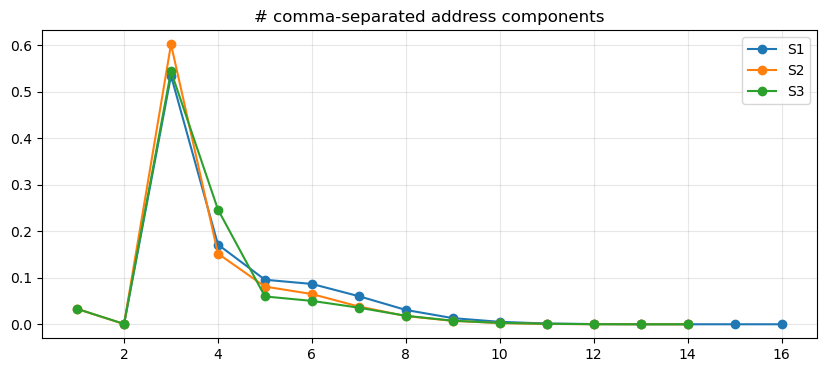

S1 India - most common last address component:


business_address,Maharashtra,Delhi,Uttar Pradesh,Karnataka,Tamil Nadu,Gujarat,West Bengal,Telangana,Haryana,Kerala,Rajasthan,Madhya Pradesh,Bihar,Andhra Pradesh,Orissa,Punjab,Mumbai,New Delhi,Bangalore,Pune
count,18094,11705,7076,6838,6010,5475,5389,5333,3501,3381,3063,2192,2139,1650,1333,1264,510,421,380,302


S2 India - most common last address component:


business_address,Maharashtra,Delhi,Uttar Pradesh,Karnataka,महाराष्ट्र,Tamil Nadu,West Bengal,Gujarat,Telangana,,दिल्ली,Haryana,Rajasthan,Andhra Pradesh,Kerala,उत्तर प्रदेश,ಕರ್ನಾಟಕ,Bihar,Madhya Pradesh,தமிழ்நாடு
count,13559,8605,5339,5226,4841,4617,4232,4189,3304,2926,2871,2585,2307,2305,2073,1872,1752,1650,1636,1505


S3 India - most common last address component:


business_address,MH,DL,UP,KA,महाराष्ट्र,TN,GJ,WB,TG,,दिल्ली,HR,RJ,KL,ಕರ್ನಾಟಕ,उत्तर प्रदेश,BR,MP,தமிழ்நாடு,পশ্চিমবঙ্গ
count,12783,7978,4867,4662,4204,4177,3841,3619,2960,2952,2731,2364,2154,1918,1571,1564,1498,1495,1358,1298


In [17]:
# Component order varies ("IA, Iowa City, 1064 Newton Rd"). Number of comma-separated components per source:
fig, ax = plt.subplots(figsize=(10, 4))
for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
    k = d.sample(200_000, random_state=SEED).business_address.str.count(",") + 1
    v = k.value_counts(normalize=True).sort_index().head(15); ax.plot(v.index.astype(int), v.values, marker="o", label=n)
ax.set_title("# comma-separated address components"); ax.legend(); plt.show()

# Last component (usually the state) - full name vs abbreviation vs native script
for n, d in [("S1", s1), ("S2", s2), ("S3", s3)]:
    last = d[d.country == "India"].sample(100_000, random_state=SEED).business_address.astype(str).str.split(",").map(lambda x: x[-1].strip())
    print(n, "India - most common last address component:"); display(last.value_counts().head(20).to_frame().T)

## 8. Pair-level similarity: true matches vs random pairs
Computed on a sample with cheap pure-Python similarities, to see which signals separate matches.

In [18]:
N_PAIRS = 30_000
s1i = s1.set_index("entity_id")
s23i = pd.concat([s2, s3], ignore_index=True).set_index("entity_id")

pos = pairs.sample(N_PAIRS, random_state=SEED)
pos = pos.join(s1i, on="s1_id").join(s23i, on="m_id", rsuffix="_m")
pos = pos.drop(columns=["country_m"]).assign(label=1)

# Negatives: random S1 x random S2/S3 record of the SAME country (harder than cross-country)
neg_parts = []
for ctry, n in pos.country.value_counts().items():
    a = s1[s1.country == ctry].sample(n, random_state=1).reset_index(drop=True)
    b = s23i[s23i.country == ctry].sample(n, random_state=2).reset_index()
    neg_parts.append(pd.DataFrame({"s1_id": a.entity_id, "m_id": b.entity_id,
                                   "business_name": a.business_name, "business_address": a.business_address,
                                   "country": a.country, "business_name_m": b.business_name,
                                   "business_address_m": b.business_address}))
neg = pd.concat(neg_parts, ignore_index=True).assign(label=0)
cols = ["s1_id", "m_id", "country", "business_name", "business_name_m", "business_address", "business_address_m", "label"]
pp = pd.concat([pos[cols], neg[cols]], ignore_index=True)
pp[cols[:-1]] = pp[cols[:-1]].astype(str)
print(pp.label.value_counts()); display(pp.sample(6, random_state=3))

label
1    30000
0    30000
Name: count, dtype: int64


,s1_id,m_id,country,business_name,business_name_m,business_address,business_address_m,label
6997,S1-89561536,S3-835764393,India,Balaji Estate Private Limited,Balaji Estate Private,"7D/2A Tashkand Marg, Civil Lines, Allahabad, Uttar Pradesh","Door No 7D/2A Tashkand Marg, Allahabad, UP",1
5808,S1-152814224,S2-920269547,US,Theresina Williams Regional Total,Theresina Williams Regional,"13401 Beaver Dam Road, Cockeysville, MD","13401 BEAVER DAM RODA, COCKEYSVILLE, MD",1
22084,S1-106648965,S2-476917586,India,Sabitri Foundation Private Limited,Sabitri Foundation Limited Services,"F No101Nishigandh Society, Sno36 1 1B 1 1 2Panchwati, Pune City, Pune, Maharashtra","DOOR NO 298 F NO101NISHIGANDH SOCIETY, SNO36 1 1B 1 1 2PANCHWATI, PUNE CITY, Maharashtra",1
9482,S1-985612538,S3-423826588,US,"Cruz, Carpenter and Voss","Cruz, Carpenter and Voss","223 Franklin Street, Pekin, IL","223 Franklin Street, N/A, Pekin, Illinois",1
30656,S1-692761306,S2-103248297,US,Great Fresh Stone Inc,BK Engineering [L.L.C.],"289 Rohavic Lane, Lino Lakes, MN","29 PINE RIDGE ROAD, SABATTUS, ME",0
27436,S1-452731741,S3-910602324,India,LW Unnati Pvt. Ltd.,LW Unnati Pvt Ltd,"Delhi, 802 Bhishm Pita Margarjun Nagar, New Delhi, South Delhi","802 Bhishm Pita Margarjun Nagar, New Delhi, South Delhi, DL",1


In [19]:
def norm(s):
    """Light normalisation: strip accents, lower-case, keep alphanumerics + spaces."""
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch)).lower()
    return re.sub(r"[^\w]+", " ", s).strip()

def tok_jacc(a, b):
    A, B = set(a.split()), set(b.split())
    return len(A & B) / len(A | B) if A | B else 0.0

def ngram_jacc(a, b, n=3):
    A = {a[i:i+n] for i in range(len(a) - n + 1)}; B = {b[i:i+n] for i in range(len(b) - n + 1)}
    return len(A & B) / len(A | B) if A | B else 0.0

def seq_ratio(a, b):
    return difflib.SequenceMatcher(None, a, b, autojunk=False).ratio()

def house_num(s):
    m = re.search(r"\d+", s); return m.group() if m else ""

feats = []
for r in pp.itertuples(index=False):
    na, nb = norm(r.business_name), norm(r.business_name_m)
    aa, ab = norm(r.business_address), norm(r.business_address_m)
    feats.append((tok_jacc(na, nb), ngram_jacc(na, nb), seq_ratio(na, nb),
                  tok_jacc(aa, ab), ngram_jacc(aa, ab),
                  float(house_num(aa) != "" and house_num(aa) == house_num(ab)),
                  float(ab == "")))
FEATS = ["name_tok_jacc", "name_3gram_jacc", "name_seq_ratio", "addr_tok_jacc", "addr_3gram_jacc",
         "same_first_number", "m_addr_empty"]
pp = pd.concat([pp, pd.DataFrame(feats, columns=FEATS)], axis=1)
display(pp.groupby("label")[FEATS].mean().T.round(3))

label,0,1
name_tok_jacc,0.030,0.642
name_3gram_jacc,0.031,0.666
name_seq_ratio,0.279,0.797
addr_tok_jacc,0.015,0.601
addr_3gram_jacc,0.024,0.644
same_first_number,0.003,0.692
m_addr_empty,0.034,0.044


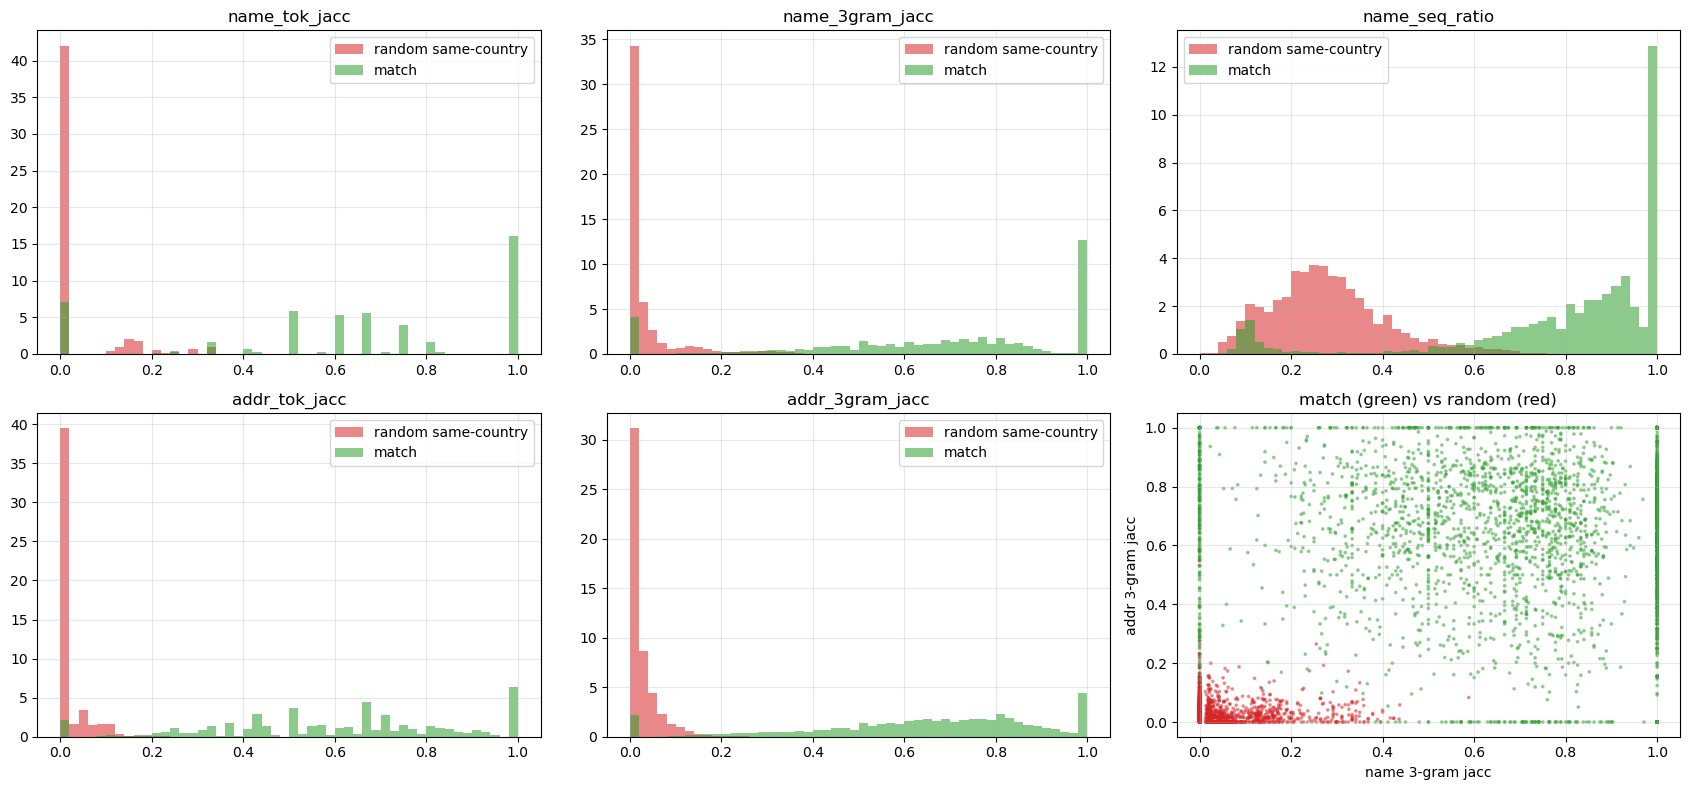

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for a, c in zip(axes.ravel(), FEATS[:5]):
    for lab, col in [(0, "tab:red"), (1, "tab:green")]:
        a.hist(pp.loc[pp.label == lab, c], bins=50, range=(0, 1), alpha=0.55, color=col, density=True,
               label="match" if lab else "random same-country")
    a.set_title(c); a.legend()
a = axes.ravel()[-1]   # 2-D view: name vs address similarity
smp = pp.sample(6000, random_state=SEED)
a.scatter(smp.name_3gram_jacc, smp.addr_3gram_jacc, c=smp.label.map({0: "tab:red", 1: "tab:green"}), s=3, alpha=0.4)
a.set_xlabel("name 3-gram jacc"); a.set_ylabel("addr 3-gram jacc"); a.set_title("match (green) vs random (red)")
plt.tight_layout(); plt.show()

In [21]:
# Hardest true matches (lowest name similarity) - what noise is behind them?
display(pp[pp.label == 1].nsmallest(15, "name_3gram_jacc")[
    ["business_name", "business_name_m", "business_address", "business_address_m", "name_3gram_jacc", "addr_3gram_jacc"]])

,business_name,business_name_m,business_address,business_address_m,name_3gram_jacc,addr_3gram_jacc
47,Ram Estate Private Limited,રામ એસ્ટેટ પ્રાઇવેટ લિમિટેડ,"Gujarat, Ahmedabad, Shripal Nagar Society Opp. Petrolpump Usmanpura, 3","NO D/704 3, AHMEDABAD, PIRANA AHMEDABAD, Gujarat",0.0,0.166667
72,Supreme Media Private Limited,సుప్రీమ్ మీడియా ప్రైవేట్ లిమిటెడ్,"2-2-25/P/7/1 Bagh Amberpet, Hyderabad, Telangana","2-2-25/P/7/1/8 BAGH AMBERPET, HYDERABAD, Andhra Pradesh",0.0,0.550000
82,Bright New Exports Private Limited,ബ്രൈറ്റ് ന്യൂ എക്സ്പോർട്സ് പ്രൈവറ്റ് ലിമിറ്റഡ്,"42/2258 C Salis Apartment, Providence Road, Ernakulam, Kanayannur, Ernakulam, Kerala","42/2258 C SALIS APARTMENT, KANAYANNUR, ERNAKULAM, Keralam",0.0,0.735294
92,Gujarat Infotech Private Limited,गुजरात इंफोटेक प्राइवेट लिमिटेड,"59/10, Sneh Sadan, J B Nagar, Ahdheri (East), Mumbai, Mumbai City, Maharashtra","Block C-4 59/10, Mumbai, Mumbai City, MH",0.0,0.229730
135,Upper Soren,Veradeltaev0,"Phoenix, 3013 27th Street, AZ","3013B 27TH ST, PHOENIX, AZ",0.0,0.468750
207,Innovative Vijay Power Private Limited,ഇന്നൊവേറ്റീവ് വിജയ് പവർ പ്രൈവറ്റ് ലിമിറ്റഡ്,"No. Xvii/186D, 1St Floor, Rambal, Yuteeka Building, Ernakulam, Kerala","Ernakulam, കേരളം, No. Xvii/9-186d, Ernakulam, 1St Floor, Rambal, Yuteeka Building",0.0,0.698630
213,Silver Healthcare Private Limited,सिल्वर हेल्थकेयर प्राइवेट लिमिटेड,"5760, Ground Floor, Street No 5, New Chandrawal, Delhi, North East, Delhi","NORTH EAST, 5760, दिल्ली",0.0,0.181818
219,Future Logistics Private Limited,फ्यूचर लॉजिस्टिक्स प्राइवेट लिमिटेड,"H No.30/3 Sec 37, Noida, Gautam Buddha Nagar, Uttar Pradesh","30/3 SEC 37, NOIDA, GAUTAM BUDDHA NAGAR, Uttar Pradesh",0.0,0.923077
226,Aditya Jay It Private Limited,आदित्य जय आईटी प्राइवेट लिमिटेड,"F P No 461, Jalgaon, Tp-Ii Near Shani Mandir, Maharashtra, Jalgaon","F P NO 461, TP-II NEAR SHANI MANDIR, INDORE, JALGAON, Maharashtra",0.0,0.761905
241,Real Foundation Private Limited,রিয়েল ফাউন্ডেশন প্রাইভেট লিমিটেড,"C/O Saijul Hoque, Vill & Po- Keshiadanga, Murshidabad, West Bengal","C/O SAIJUL HOQUE, VILL & PO- KESHIADANGA, MURSHIDABAD, West Bengal",0.0,1.000000


In [22]:
# Similarity of true matches by country and by source (S2 vs S3)
pp["m_src"] = pp.m_id.str[:2]
display(pp[pp.label == 1].groupby(["country", "m_src"])[
    ["name_3gram_jacc", "addr_3gram_jacc", "same_first_number", "m_addr_empty"]].mean().round(3))

name_3gram_jacc  addr_3gram_jacc  same_first_number  m_addr_empty
country m_src                                                                   
India   S2               0.548            0.744              0.627         0.039
        S3               0.591            0.605              0.636         0.039
US      S2               0.738            0.668              0.727         0.047
        S3               0.723            0.587              0.738         0.047

## 9. Blocking-key recall preview
Recall of simple blocking keys on the true pairs (share of true pairs whose two records share the key), plus
how large the blocks would be on S2+S3. A good blocking scheme is a **union** of several keys with high combined recall and small blocks.

In [23]:
STOP = {"the", "sri", "shri", "dr", "m", "s", "mr", "smt"}
def first_name_tok(s):
    toks = [t for t in norm(s).split() if t not in STOP]
    return toks[0] if toks else ""
def name_prefix4(s): return norm(s).replace(" ", "")[:4]
def longest_name_tok(s):   # order-invariant key: robust to word transpositions
    toks = [t for t in norm(s).split() if t not in STOP]
    return max(toks, key=len) if toks else ""

KEYS = {
    "name first token":   ("business_name", first_name_tok),
    "name first 4 chars": ("business_name", name_prefix4),
    "name longest token": ("business_name", longest_name_tok),
    "addr first number":  ("business_address", lambda s: house_num(norm(s))),
}
tp = pp[pp.label == 1]
hits = {}
for k, (col, f) in KEYS.items():
    a = tp[col].map(f); b = tp[col + "_m"].map(f)
    hits[k] = ((a == b) & (a != "")).to_numpy()
res = {k: v.mean() for k, v in hits.items()}
res["UNION of above"] = np.logical_or.reduce(list(hits.values())).mean()
display(pd.Series(res, name="recall on true pairs").round(4).to_frame())

,recall on true pairs
name first token,0.7630
name first 4 chars,0.7641
name longest token,0.6815
addr first number,0.6925
UNION of above,0.9615


blocks: 94032 | median est. size: 20 | p99: 887 | max: 85761


,est_block_size
India|private,85761.0
US|llc,80890.0
US|pediatric,59568.0
US|inc,58701.0
India|limited,36327.0
India|स,33066.0
India|pvt,29557.0
India|new,29227.0
US|family,26110.0
India|ग,24067.0


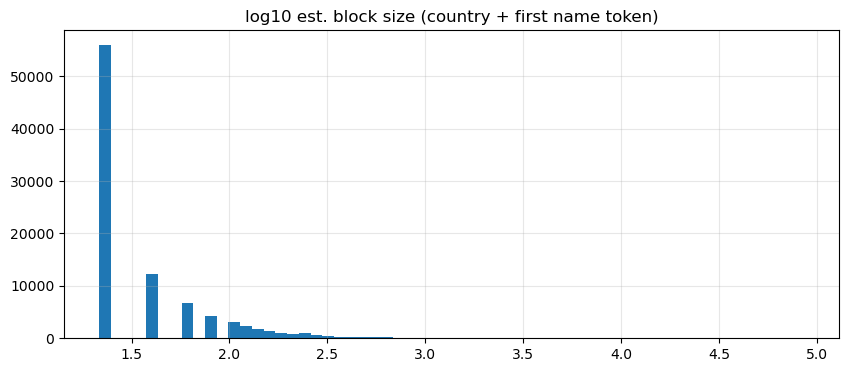

In [24]:
# Block-size estimate for "country + name first token" on a 500k sample of S2+S3 (scaled to full size)
smp = s23i.sample(500_000, random_state=SEED)
key = smp.country.astype(str) + "|" + smp.business_name.astype(str).map(first_name_tok)
bs = key.value_counts() * len(s23i) / len(smp)
print("blocks:", len(bs), "| median est. size:", int(bs.median()), "| p99:", int(bs.quantile(0.99)), "| max:", int(bs.max()))
display(bs.head(15).round(0).to_frame("est_block_size"))
plt.hist(np.log10(bs + 1), bins=60); plt.title("log10 est. block size (country + first name token)"); plt.show()

## 10. Test set overview (incl. France)

saved d:\downloads\hackathon\amazon ml  challenge\6a7c763e089e4_aic_2026\student_resource\eda_artifacts\pair_sample_with_feats.parquet


,T1,T2,T3
country,,,
India,809986,2312565,2405000
US,663106,1871330,1945701
France,259452,703378,731615


ratio (S2+S3)/S1  train: 4.68  test: 5.75


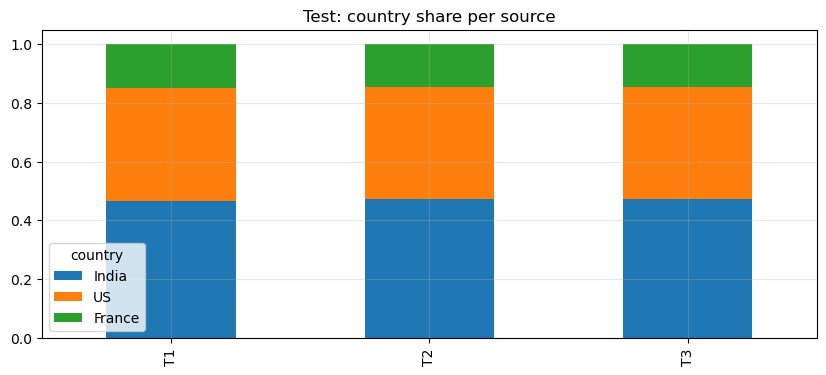

In [25]:
# Save labelled pair sample for quick feature prototyping later
out = ROOT / "eda_artifacts"; out.mkdir(exist_ok=True)
pp.to_parquet(out / "pair_sample_with_feats.parquet", index=False)
print("saved", out / "pair_sample_with_feats.parquet")

# Free big train frames before loading test (RAM is limited)
n_tr = {"S1": len(s1), "S23": len(s23i)}
del s23i, s1i, s2, s3, pos, neg, neg_parts, smp, key; gc.collect()

t1 = load_tsv(DATA / "test/test_source1.tsv")
t2 = load_tsv(DATA / "test/test_source2.tsv")
t3 = load_tsv(DATA / "test/test_source3.tsv")
tc = pd.DataFrame({n: d.country.value_counts() for n, d in [("T1", t1), ("T2", t2), ("T3", t3)]}).fillna(0).astype(int)
display(tc)
print("ratio (S2+S3)/S1  train:", round(n_tr["S23"] / n_tr["S1"], 2), " test:", round((len(t2) + len(t3)) / len(t1), 2))
(tc / tc.sum()).T.plot.bar(stacked=True, title="Test: country share per source"); plt.show()

In [26]:
for n, d in [("T1", t1), ("T2", t2), ("T3", t3)]:
    print(n); display(d[d.country == "France"].sample(8, random_state=SEED))

T1


,entity_id,business_name,business_address,country
1630454,S1-41726612,Mediation Visages Fetes EURL,"Dunkerque, 3 Rue de la Bienfaisance, Hauts-de-France",France
1671022,S1-845965189,Lille Club,"15 BIS Rue d'Arcole, Lille, Hauts-de-France",France
1660454,S1-881396111,Amicale du Usine,"41 Place de la Cinquième République, Pessac, Nouvelle-Aquitaine",France
1729757,S1-657417418,Pharmacie Dame,"26 Rue Mercière, Bordeaux, Nouvelle-Aquitaine",France
608569,S1-872609724,Nantes Sport SARL,"Pays de la Loire, 29 Rue du Fezzan, Nantes",France
13664,S1-692990298,Établissements Faire,"7 Avenue de la Reousse Dune l'Herbe, Lège-Cap-Ferret, Nouvelle-Aquitaine",France
820401,S1-357802158,Foire Maternelle EURL,"83 Rue de Laseppe, Bordeaux, Nouvelle-Aquitaine",France
545800,S1-150454433,Maison Formule,"22 Rue de Mons, Roubaix, Hauts-de-France",France


T2


,entity_id,business_name,business_address,country
1429706,S2-19087216,JX Sportive,"30 RUE DE MENIN, TOURCOING, Nord",France
2624124,S2-824918948,ASSOCIATION DE VALOIS EURL,"N° 14 R. DE BOULMGNE, TOURCOING",France
1389843,S2-533464750,École primaire International SCI,"NO 12 RUE LOUIS BRALLE, BORDEAUX",France
1762538,S2-677480728,Pontet Ecole SAS,"57 RUE DE LA VILLE EN PIERRE, NANTES, Pays de la Loire",France
1778536,S2-11241777,Sociale Chu Comite SARL,"Hauts-de-France, NO. 14 RUE MONSEIGNEUR PIEDFORT, CALAIS",France
3715606,S2-751420807,Trois & Frèrês Développement SA,"56 - RTE DES QUATRE VENTS, SAINT-NAZAIRE, Loire-Atlantique",France
1842323,S2-854158318,3eme Culturelle (Frànce),"1 BD. DU MASSACRE, SAINT-HERBLAIN, Loire-Atlantique",France
2352540,S2-943119084,MQG Amicale,"005 PLACE DES BASQUES, BORDEAUX, Nouvelle-Aquitaine",France


T3


,entity_id,business_name,business_address,country
364691,S3-366461218,Tourcoing Loisirs,"N°94 R Des Champs, Tourcoing",France
3267384,S3-911557245,Vigan SASU Comite,"8 Rue André Chenier, Lille, Hauts-de-France",France
2966655,S3-295250807,Bureau SAS Fetes (France),"23 Bis Rue De Caulet, Bordeaux",France
3418848,S3-889785051,@Alissasmaternelle,"115 R. Dupuy De Lôme, Roubaix, Nord",France
1948987,S3-717904579,Team Ecole E.U.R.L.,"19 R La Clairière Des Ontiens, Mérignac, Gironde",France
2880204,S3-584659989,entente comite (france),"361 R. Jules Guesde, Roubaix",France
1914035,S3-521711221,BLP Immôbilier SA,"9 Rue Paul Painlevé, Tourcoing",France
2842059,S3-89844898,Balade Primaire (France) E.U.R.L.,"R. De Gnad, Tourcoing, Nord",France


In [27]:
# France-specific patterns: legal suffixes & street words (useful for normalisation maps, no labels needed)
fr = pd.concat([d[d.country == "France"] for d in (t1, t2, t3)], ignore_index=True)
print("France last name tokens:")
display(last_tok(fr.business_name.sample(100_000, random_state=SEED)).value_counts().head(25).to_frame().T)
st = Counter()
for t in fr.business_address.sample(100_000, random_state=SEED).str.lower().tolist():
    st.update(re.findall(r"[a-zà-ÿ\.]+", t))
print("France common address tokens:"); display(pd.DataFrame(st.most_common(40), columns=["tok", "n"]).set_index("tok").T)
print("France 5-digit postcode present:", round(fr.business_address.str.contains(r"\b\d{5}\b", regex=True).mean(), 3))

France last name tokens:


business_name,sarl,sas,eurl,sa,sasu,sci,france,groupe,fils,club,...,international,amicale,snc,holding,comite,participations,sàrl,sportive,services,associés
count,18214,13838,5578,4524,4017,3534,2245,1543,1509,1469,...,828,818,796,793,788,786,735,662,661,606


France common address tokens:


tok,de,rue,la,loire,france,hauts,bordeaux,aquitaine,nouvelle,nantes,...,cap,ferret,bis,mérignac,pornic,no,l,d,herblain,baule
n,61895,42976,28340,19732,17256,17063,16351,14291,14287,14066,...,3593,3527,3404,3175,3034,2881,2854,2824,2647,2608


France 5-digit postcode present: 0.005


## Key takeaways (fill in after running)
- Singleton rate: ...  -> an empty prediction is often right; the threshold should be conservative (F0.5).
- S2/S3 distractor share: ...
- Scripts: native Indian scripts in names/states -> transliteration / script-agnostic features needed.
- Name noise: junk prefixes, bracket wrappers, word reordering, DBA/formerly, domains, honorifics -> normalise and use order-invariant token features.
- Address: format/case/order varies; house-number and postcode agreement look like strong signals.
- Blocking: a union of several keys (name token, name prefix, house number, char-n-gram TF-IDF ANN) is needed for high recall.
- France: unseen in train -> rely on language-agnostic string similarity, not country-specific features.